In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from pandas import IndexSlice as idx
import os
from tqdm import tqdm
from pathlib import Path
from collections import deque
from IPython.display import clear_output
import time
from dataclasses import dataclass
from typing import Tuple


# FactorBacktestEngine

In [92]:
# =========================
# Helpers
# =========================
def _to_dt_index(idx) -> pd.DatetimeIndex:
    """Ensure DatetimeIndex."""
    if isinstance(idx, pd.DatetimeIndex):
        return idx
    return pd.to_datetime(idx)

def _month_end_dates(dti: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """
    Month-end rebalance dates based on existing trading days in index:
    for each month, take the last date appearing in factor index.
    """
    s = pd.Series(dti, index=dti)
    me = s.groupby(dti.to_period("M")).max().values
    return pd.DatetimeIndex(me).sort_values().unique()

def _cs_pearson_ic(x: pd.Series, y: pd.Series) -> float:
    m = x.notna() & y.notna()
    if m.sum() < 2:
        return np.nan
    return float(np.corrcoef(x[m].values, y[m].values)[0, 1])

def _cs_spearman_ic(x: pd.Series, y: pd.Series) -> float:
    m = x.notna() & y.notna()
    if m.sum() < 2:
        return np.nan
    xr = x[m].rank(method="average")
    yr = y[m].rank(method="average")
    return float(np.corrcoef(xr.values, yr.values)[0, 1])

def _nav_from_ret(ret: pd.Series) -> pd.Series:
    return (1.0 + ret.fillna(0.0)).cumprod()

def _max_drawdown(nav: pd.Series) -> float:
    peak = nav.cummax()
    dd = nav / peak - 1.0
    return float(dd.min())  # negative

def _format_pct(x: float, decimals=2) -> str:
    if pd.isna(x):
        return ""
    return f"{x*100:.{decimals}f}%"

def _format_num(x: float, decimals=2) -> str:
    if pd.isna(x):
        return ""
    return f"{x:.{decimals}f}"

def _ann_stats_from_daily_ret(ret: pd.Series, nav: pd.Series) -> Tuple[float, float, float, float, float]:
    """
    Return:
      ann_ret, ann_vol, ir, max_dd, monthly_win_rate
    """
    r = ret.dropna()
    if len(r) <= 2:
        return (np.nan, np.nan, np.nan, np.nan, np.nan)

    ann_ret = (nav.iloc[-1] / nav.iloc[0]) ** (252 / len(r)) - 1.0
    ann_vol = r.std(ddof=1) * np.sqrt(252)
    ir = ann_ret / ann_vol if ann_vol != 0 else np.nan
    mdd = _max_drawdown(nav)

    me = _month_end_dates(nav.index)
    me_nav = nav.reindex(me).dropna()
    me_ret = me_nav.pct_change()
    mwin = float((me_ret > 0).mean()) if len(me_ret.dropna()) > 0 else np.nan

    return (ann_ret, ann_vol, ir, mdd, mwin)


# =========================
# Result container
# =========================
@dataclass
class BacktestResult:
    ic_series: pd.DataFrame                 # index=rebalance_date, cols=[IC, RankIC]
    group_daily_ret: pd.DataFrame           # index=daily dates, cols=[G1..G5]
    ls_daily_ret: pd.Series                 # index=daily dates
    group_nav: pd.DataFrame                 # index=daily dates, cols=[G1..G5]
    ls_nav: pd.Series                       # index=daily dates
    yearly_table: pd.DataFrame              # index=year, col=YearReturn (pct str)
    summary_table: pd.DataFrame             # 1-row df, 12 metrics (strings)


# =========================
# Engine (compute only)
# =========================
class FactorBacktestEngine:
    """
    Single-factor monthly rebalancing backtest engine.
    Inputs:
      - factor: DataFrame, index=trade_date, columns=ts_code
      - stock_daily: DataFrame with MultiIndex (trade_date, ts_code), columns include:
            close, is_st, is_limit
    Output:
      - BacktestResult (NO PLOTS inside)
    """
    def __init__(self, n_group: int = 5):
        self.n_group = int(n_group)

    def _align_inputs(
        self,
        factor: pd.DataFrame,
        stock_daily: pd.DataFrame
    ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        """
        Return:
          factor_aligned (date x code),
          stock_price (date x code),
          tradable_mask (date x code) True=tradable
        """
        factor = factor.copy()
        stock_daily = stock_daily.copy()

        # factor index
        factor.index = _to_dt_index(factor.index)
        factor = factor.sort_index()

        # stock_daily index -> date level to datetime
        if not isinstance(stock_daily.index, pd.MultiIndex):
            raise ValueError("stock_daily must be MultiIndex with levels ['trade_date','ts_code'].")

        # normalize index names if needed
        if stock_daily.index.names[0] != "trade_date":
            stock_daily.index = stock_daily.index.set_names(["trade_date", stock_daily.index.names[1]])
        if stock_daily.index.names[1] != "ts_code":
            stock_daily.index = stock_daily.index.set_names([stock_daily.index.names[0], "ts_code"])

        # ensure datetime for trade_date level
        trade_dates = _to_dt_index(stock_daily.index.get_level_values("trade_date"))
        stock_daily = stock_daily.copy()
        stock_daily.index = pd.MultiIndex.from_arrays(
            [trade_dates, stock_daily.index.get_level_values("ts_code")],
            names=["trade_date", "ts_code"]
        )
        stock_daily = stock_daily.sort_index()

        # build matrices
        close = stock_daily["close"].unstack("ts_code")
        is_st = stock_daily["is_st"].unstack("ts_code")          # 0/1
        is_limit = stock_daily["is_limit"].unstack("ts_code")    # bool

        close.index = _to_dt_index(close.index)
        close = close.sort_index()

        # align dates + codes
        common_dates = factor.index.intersection(close.index)
        common_cols = factor.columns.intersection(close.columns)

        factor = factor.loc[common_dates, common_cols]
        close = close.loc[common_dates, common_cols]
        is_st = is_st.loc[common_dates, common_cols]
        is_limit = is_limit.loc[common_dates, common_cols]

        factor = factor.dropna(how="all")
        close = close.reindex(factor.index)
        is_st = is_st.reindex(factor.index)
        is_limit = is_limit.reindex(factor.index)

        # tradable mask: not ST and not limit and price exists
        tradable = (is_st.fillna(0) == 0) & (~is_limit.fillna(False)) & close.notna()

        # key: set factor=NaN where not tradable (your requirement)
        factor = factor.mask(~tradable)

        return factor, close, tradable

    def compute_monthly_ic(self, factor: pd.DataFrame, stock_price: pd.DataFrame) -> pd.DataFrame:
        me = _month_end_dates(factor.index)

        ic_list = []
        for i in range(len(me) - 1):
            d0, d1 = me[i], me[i + 1]
            if d0 not in stock_price.index or d1 not in stock_price.index:
                continue

            f = factor.loc[d0]
            r = stock_price.loc[d1] / stock_price.loc[d0] - 1.0

            ic = _cs_pearson_ic(f, r)
            ric = _cs_spearman_ic(f, r)
            ic_list.append((d0, ic, ric))

        return pd.DataFrame(ic_list, columns=["trade_date", "IC", "RankIC"]).set_index("trade_date")

    def _build_group_and_ls_returns(self, factor: pd.DataFrame, stock_price: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
        daily_ret = stock_price.pct_change()
        me = _month_end_dates(factor.index)

        group_cols = [f"G{i+1}" for i in range(self.n_group)]
        group_daily_ret = pd.DataFrame(index=factor.index, columns=group_cols, dtype="float64")
        ls_daily_ret = pd.Series(index=factor.index, dtype="float64", name="LS")

        for i in range(len(me) - 1):
            reb, nxt = me[i], me[i + 1]
            window = factor.index[(factor.index > reb) & (factor.index <= nxt)]
            if len(window) == 0:
                continue

            # factor at reb already masked by tradable rule
            f = factor.loc[reb].dropna()
            if len(f) < self.n_group:
                continue

            ranks = f.rank(method="first")
            try:
                grp = pd.qcut(ranks, self.n_group, labels=False)  # 0..n_group-1
            except ValueError:
                continue

            for gi in range(self.n_group):
                members = grp.index[grp == gi]
                if len(members) == 0:
                    continue
                r = daily_ret.loc[window, members].mean(axis=1)
                group_daily_ret.loc[window, f"G{gi+1}"] = r.values

            # Long-Short = G1 - G5 (your direction)
            g1 = grp.index[grp == 0]
            g5 = grp.index[grp == (self.n_group - 1)]
            if len(g1) > 0 and len(g5) > 0:
                r_g1 = daily_ret.loc[window, g1].mean(axis=1)
                r_g5 = daily_ret.loc[window, g5].mean(axis=1)
                ls_daily_ret.loc[window] = (r_g1 - r_g5).values

        return group_daily_ret.astype("float64"), ls_daily_ret.astype("float64")

    def yearly_return_table(self, nav: pd.Series) -> pd.DataFrame:
        yr = nav.groupby(nav.index.year).apply(lambda x: x.iloc[-1] / x.iloc[0] - 1.0)
        out = pd.DataFrame({"YearReturn": yr})
        out["YearReturn"] = out["YearReturn"].map(lambda v: _format_pct(v, 2))
        out.index.name = "Year"
        return out

    def summary_table(
        self,
        ic_df: pd.DataFrame,
        group_daily_ret: pd.DataFrame,
        ls_daily_ret: pd.Series,
        group_nav: pd.DataFrame,
        ls_nav: pd.Series
    ) -> pd.DataFrame:
        # ---- IC stats (monthly) ----
        ic_mean = ic_df["IC"].mean()
        ic_std = ic_df["IC"].std(ddof=1)
        icir = ic_mean / ic_std if pd.notna(ic_std) and ic_std != 0 else np.nan

        ric_mean = ic_df["RankIC"].mean()
        ric_std = ic_df["RankIC"].std(ddof=1)
        ricir = ric_mean / ric_std if pd.notna(ric_std) and ric_std != 0 else np.nan

        # ---- Long-Short stats (daily) ----
        ls_ann_ret, ls_ann_vol, ls_ir, ls_mdd, ls_mwin = _ann_stats_from_daily_ret(ls_daily_ret, ls_nav)

        # ---- Long-only stats (use G1) ----
        long_ret = group_daily_ret["G1"]
        long_nav = group_nav["G1"]
        long_ann_ret, long_ann_vol, long_ir, _, _ = _ann_stats_from_daily_ret(long_ret, long_nav)

        data = {
            # 4 IC metrics
            "IC_mean": _format_pct(ic_mean, 2),
            "ICIR": _format_num(icir, 2),
            "RankIC_mean": _format_pct(ric_mean, 2),
            "RankICIR": _format_num(ricir, 2),

            # 5 Long-Short metrics
            "LS_AnnRet": _format_pct(ls_ann_ret, 2),
            "LS_AnnVol": _format_pct(ls_ann_vol, 2),
            "LS_IR": _format_num(ls_ir, 2),
            "LS_MaxDD": _format_pct(ls_mdd, 2),
            "LS_MonthlyWinRate": _format_pct(ls_mwin, 2),

            # 3 Long-only metrics
            "Long_AnnRet": _format_pct(long_ann_ret, 2),
            "Long_AnnVol": _format_pct(long_ann_vol, 2),
            "Long_IR": _format_num(long_ir, 2),
        }
        return pd.DataFrame([data])

    def run(self, factor: pd.DataFrame, stock_daily: pd.DataFrame) -> BacktestResult:
        factor, stock_price, _tradable = self._align_inputs(factor, stock_daily)

        ic_df = self.compute_monthly_ic(factor, stock_price)
        group_daily_ret, ls_daily_ret = self._build_group_and_ls_returns(factor, stock_price)

        group_nav = group_daily_ret.apply(_nav_from_ret, axis=0)
        ls_nav = _nav_from_ret(ls_daily_ret)

        yearly_tbl = self.yearly_return_table(ls_nav)
        summary_tbl = self.summary_table(ic_df, group_daily_ret, ls_daily_ret, group_nav, ls_nav)

        return BacktestResult(
            ic_series=ic_df,
            group_daily_ret=group_daily_ret,
            ls_daily_ret=ls_daily_ret,
            group_nav=group_nav,
            ls_nav=ls_nav,
            yearly_table=yearly_tbl,
            summary_table=summary_tbl
        )


# =========================
# Plot / display modules (standalone, directly show)
# =========================
def plot_rankic(ic_df: pd.DataFrame, factor_name: str):
    fig, ax = plt.subplots(figsize=(14, 3))

    ax.bar(ic_df.index.astype(str), ic_df["RankIC"].values)
    ax.axhline(0)
    ax.set_title(f"{factor_name} | RankIC (Monthly)")
    ax.tick_params(axis="x", rotation=90)

    fig.tight_layout()
    plt.show()


def plot_group_annualized_return(group_daily_ret: pd.DataFrame, factor_name: str, trading_days: int = 252):
    group_nav = group_daily_ret.apply(_nav_from_ret, axis=0)

    ann = {}
    for c in group_nav.columns:
        nav = group_nav[c].dropna()
        if len(nav) < 2:
            ann[c] = np.nan
            continue
        n_days = len(nav) - 1
        ann[c] = (nav.iloc[-1] / nav.iloc[0]) ** (trading_days / n_days) - 1.0

    ann_s = pd.Series(ann).reindex(group_nav.columns)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(ann_s.index, ann_s.values * 100.0)
    ax.axhline(0)

    ymin = min(0.0, float(np.nanmin(ann_s.values) * 100.0) * 1.2 if np.isfinite(np.nanmin(ann_s.values)) else 0.0)
    ymax = max(0.0, float(np.nanmax(ann_s.values) * 100.0) * 1.2 if np.isfinite(np.nanmax(ann_s.values)) else 0.0)
    ax.set_ylim(ymin, ymax)

    ax.set_ylabel("Annualized Return (%)")
    ax.set_title(f"{factor_name} | Group Annualized Return")
    plt.show()


def plot_group_nav(group_nav: pd.DataFrame, factor_name: str):
    fig, ax = plt.subplots(figsize=(12, 5))

    for c in group_nav.columns:
        ax.plot(group_nav.index, group_nav[c], label=c)

    ax.set_title(f"{factor_name} | Group NAV Curves")
    ax.legend(loc="upper left")

    fig.tight_layout()
    plt.show()


def plot_ls_nav_and_drawdown(ls_nav: pd.Series, factor_name: str):
    nav = ls_nav.dropna()
    peak = nav.cummax()
    dd_neg = nav / peak - 1.0            # <= 0
    dd_pos = (-dd_neg).clip(lower=0.0)   # >= 0 drawdown magnitude

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(nav.index, nav.values, label="Long-Short NAV")
    ax1.set_title(f"{factor_name} | Long-Short NAV & Drawdown")
    ax1.legend(loc="lower center")

    ax2 = ax1.twinx()
    ax2.fill_between(dd_pos.index, 0, dd_pos.values, alpha=0.35, color="red", label="Drawdown (Right Axis)")

    dd_max = float(dd_pos.max()) if np.isfinite(dd_pos.max()) else 0.1
    ax2.set_ylim(dd_max * 1.05, 0)  # invert: top=0, bottom=positive
    ax2.set_ylabel("Drawdown (Right Axis)")

    fig.tight_layout()
    plt.show()

def plot_ls_nav(res_dict: dict, title: str = "Long-Short NAV Comparison"):
    fig, ax = plt.subplots(figsize=(12, 5))

    for name, res in res_dict.items():
        nav = res.ls_nav.dropna()
        ax.plot(nav.index, nav.values, label=name)

    ax.set_title(title)
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()

def compare_summary_table(res_dict: dict):
    """
    Parameters
    ----------
    res_dict : dict
        {factor_name: BacktestResult}

    Effect
    ------
    Display a comparison summary table:
      - rows   : metrics
      - columns: factor names
    """
    tables = {}

    for factor_name, res in res_dict.items():
        if not hasattr(res, "summary_table"):
            raise ValueError(f"{factor_name} has no summary_table")

        # summary_table: 1-row DataFrame
        s = res.summary_table.iloc[0]
        tables[factor_name] = s

    summary_cmp = pd.DataFrame(tables)

    metric_order = [
        "IC_mean", "ICIR",
        "RankIC_mean", "RankICIR",
        "LS_AnnRet", "LS_AnnVol", "LS_IR", "LS_MaxDD", "LS_MonthlyWinRate",
        "Long_AnnRet", "Long_AnnVol", "Long_IR"
    ]
    summary_cmp = summary_cmp.reindex(metric_order)

    display(summary_cmp)


def show_yearly_table(yearly_table: pd.DataFrame):
    display(yearly_table)

def show_summary_table(summary_table: pd.DataFrame):
    display(summary_table)


# Data Preparation

### Daily Stock Data Retrieval

In [68]:
# Read daily stock market data (MultiIndex: ['trade_date', 'ts_code'])
stock_daily = pd.read_parquet('/Users/zhaoweizhi/Desktop/Quant_Research/data/stock_daily.parquet')

# -----------------------------
# Apply forward adjustment to daily price data
# -----------------------------

# Price-related fields to be forward-adjusted
px_cols = ['open', 'high', 'low', 'close', 'pre_close', 'up_limit', 'down_limit']

# To ensure the "last row" represents the latest trading day,
# first swap the index to ['ts_code', 'trade_date'] and sort
stock_daily = stock_daily.swaplevel('trade_date', 'ts_code').sort_index()

# Group by stock code
g = stock_daily.groupby(level='ts_code', sort=False)

# Take the adjustment factor of the last row for each stock as the common base factor
latest_adj = g['adj_factor'].transform('last')

# Compute the forward adjustment multiplier: daily adj_factor / latest adj_factor
mult = stock_daily['adj_factor'] / latest_adj

# Apply forward adjustment to price fields and overwrite original columns (keep 2 decimals)
stock_daily[px_cols] = stock_daily[px_cols].mul(mult, axis=0).round(2)

# Recompute price change using adjusted prices
stock_daily['change'] = (stock_daily['close'] - stock_daily['pre_close']).round(2)

# Compute percentage change using adjusted prices
# Keep 4 decimals first, then convert to percent and keep 2 decimals
ret4 = (stock_daily['change'] / stock_daily['pre_close']).replace([np.inf, -np.inf], np.nan)
stock_daily['pct_chg'] = (ret4.round(4) * 100).round(2)

# Restore index order to ['trade_date', 'ts_code'] for subsequent time-series processing
stock_daily = stock_daily.swaplevel('ts_code', 'trade_date').sort_index()

# Determine whether the stock hit limit up/down on the day
stock_daily['is_limit'] = (stock_daily['close'] >= stock_daily['up_limit']) | (stock_daily['close'] <= stock_daily['down_limit'])

stock_daily = stock_daily[['close','is_st','is_limit']]


In [69]:
stock_daily

close  is_st  is_limit
trade_date ts_code                           
2017-01-03 000001.SZ    7.13      0     False
           000002.SZ   15.15      0     False
           000004.SZ   44.45      0     False
           000005.SZ    6.83      0     False
           000006.SZ    7.92      0     False
...                      ...    ...       ...
2025-11-28 920978.BJ   34.63      0     False
           920981.BJ   31.74      0     False
           920982.BJ  217.27      0     False
           920985.BJ    8.56      0     False
           920992.BJ   17.58      0     False

[9363751 rows x 3 columns]

### Compute the Median 1-Minute Return Across All Stocks in the Market

In [73]:
# ================== Paths & Parameters ==================
MIN_FOLDER = Path('/Users/zhaoweizhi/Desktop/Quant_Research/data/stock_1min/')
DROP_HHMM = {'14:58', '14:59'}

# ================== Stock File Mapping ==================
files = {fp.stem: fp for fp in MIN_FOLDER.glob('*.parquet')}

# ================== Trading Date List (from stock_daily) ==================
trade_dates = sorted(
    stock_daily.index.get_level_values('trade_date').unique()
)

out_rows = []

# ================== Main Loop: compute market median minute-by-minute returns by day ==================
t0 = time.time()

for di, d in enumerate(trade_dates, start=1):

    # Stocks traded on the day
    ts_today = stock_daily.xs(d, level='trade_date').index.tolist()
    if not ts_today:
        continue

    minute_grid = None
    ret_list = []

    n_today = len(ts_today)

    for ti, ts in enumerate(ts_today, start=1):

        # ======= Progress display (reduce refresh frequency to avoid slowdown) =======
        if (ti == 1) or (ti % 200 == 0) or (ti == n_today):
            clear_output(wait=True)
            elapsed = time.time() - t0
            print(
                f"Processing {di}/{len(trade_dates)} days | date={d} | "
                f"stock {ti}/{n_today}: {ts} | elapsed={elapsed:.1f}s"
            )

        fp = files.get(ts)
        if fp is None:
            continue

        # ======= Core speed-up points 1 & 2: no sort + read only required columns =======
        df = pd.read_parquet(fp, columns=['close', 'adj_factor'])

        # Get intraday minute data for the date
        try:
            day = df.xs(d, level='trade_date', drop_level=False)
        except KeyError:
            continue

        # Forward adjustment
        latest_adj = df['adj_factor'].iloc[-1]
        close = (day['close'] * (day['adj_factor'] / latest_adj)).round(2)

        # Drop 14:58 / 14:59
        t = close.index.get_level_values('trade_time')
        mask = ~pd.Index(t.strftime('%H:%M')).isin(DROP_HHMM)
        close = close.loc[mask]

        # Use trade_time as the minute index
        close.index = close.index.get_level_values('trade_time')

        # Build minute grid (use only the first successful stock)
        if minute_grid is None:
            minute_grid = close.index

        # Intraday 1min ret (no cross-day)
        ret = close.pct_change()

        # Align to minute grid
        ret = ret.reindex(minute_grid)

        ret_list.append(ret.values)

    # No valid stocks on the day
    if not ret_list:
        continue

    # ================== NumPy cross-sectional median ==================
    mat = np.vstack(ret_list).T            # shape = (minutes, stocks)
    med = np.nanmedian(mat, axis=1)        # market median per minute

    # ================== Append to results ==================
    out_rows.append(
        pd.DataFrame({
            'trade_date': d,
            'trade_time': minute_grid,
            'mkt_median_ret': med
        })
    )

# ================== Combine into one DataFrame (in memory) ==================
clear_output(wait=True)
print("Done. Building mkt_median_df ...")

mkt_median_df = pd.concat(out_rows, ignore_index=True)
mkt_median_df.set_index(['trade_date', 'trade_time'], inplace=True)

print("Finished:", mkt_median_df.shape)
print("Total elapsed:", time.time() - t0, "seconds")


Done. Building mkt_median_df ...
Finished: (516957, 1)
Total elapsed: 319424.69677591324 seconds


In [6]:
mkt_median_df

mkt_median_ret
trade_date trade_time                         
2017-01-03 2017-01-03 09:30:00             NaN
           2017-01-03 09:31:00        0.001451
           2017-01-03 09:32:00        0.000000
           2017-01-03 09:33:00        0.000000
           2017-01-03 09:34:00        0.000000
...                                        ...
2025-11-28 2025-11-28 14:54:00        0.000000
           2025-11-28 14:55:00        0.000000
           2025-11-28 14:56:00        0.000000
           2025-11-28 14:57:00        0.000000
           2025-11-28 15:00:00        0.000000

[516957 rows x 1 columns]

In [81]:
# Computing mkt_median_df is very time-consuming, so save it locally once it is obtained
mkt_median_df.to_parquet('stock_mkt_1min_ret_median.parquet')

# 1. Identification of Momentum-Chasing Price Patterns
For identifying momentum-chasing price patterns, we measure such behavior using the autocorrelation of minute-level returns. If a stock experiences a sharp price increase at the current time t, accompanied by a continued increase at the next time t+1, the autocorrelation of minute returns will be high, indicating strong momentum-chasing characteristics. Such stocks typically have a higher proportion of retail investor trading activity, and correspondingly higher future risk.

Based on this logic, we select 1-minute frequency data over the past 20 trading days. By computing the cosine similarity between the excess return series of consecutive minutes, we construct a simple full-period momentum-chasing factor. (The detailed construction steps are shown in Table 1.)

Table 1: Construction Steps of the Full-Period Momentum-Chasing Factor

| Step | Description |
|------|-------------|
| Step 1 | Select 1-minute frequency trading data for the past 20 trading days of each stock; |
| Step 2 | Compute the excess return at time t and the excess return at the next minute t+1, denoted as \( R_{t} \) and \( R_{t+1} \); |
| Step 3 | Calculate the cosine similarity between \( R_{t} \) and \( R_{t+1} \) as the value of the momentum-chasing factor. |

Key Points in Constructing the Full-Period Momentum-Chasing Factor

In the construction of the full-period momentum-chasing factor, there are two aspects worth discussing:

（1）Absolute returns vs. excess returns: We use minute-level excess returns (absolute returns minus the market median) to remove the impact of market beta on minute returns;

（2）Correlation coefficient vs. cosine similarity: From the formulas of the correlation coefficient and cosine similarity, the only difference between the two is that cosine similarity does not subtract the mean return, allowing it to better capture both directional following and magnitude following.

Correlation coefficient:

$$
\rho=\frac{\sum_{t=1}^{n-1}\left(R_{t}-\overline{R_{t}}\right)\left(R_{t+1}-\overline{R_{t+1}}\right)}{\sqrt{\sum_{t=1}^{n-1}\left(R_{t}-\overline{R_{t}}\right)^{2}\sum_{t=1}^{n-1}\left(R_{t+1}-\overline{R_{t+1}}\right)^{2}}}
$$

Cosine similarity:

$$
\rho=\frac{\sum_{t=1}^{n-1} R_{t} R_{t+1}}{\sqrt{\sum_{t=1}^{n-1} R_{t}^{2} \sum_{t=1}^{n-1} R_{t+1}^{2}}}
$$

By combining the above two choices pairwise, we construct four different full-period momentum-chasing factors and compare their performance. Unless otherwise stated, the testing period in this study spans from 2017-01-01 to 2025-11-30, and factor backtests adopt a monthly rebalancing scheme.


In [12]:
MIN_FOLDER = Path('/Users/zhaoweizhi/Desktop/Quant_Research/data/stock_1min/')
DROP_HHMM = {'14:58', '14:59'}

codes = sorted(stock_daily.index.get_level_values('ts_code').unique())

def _corr_nan(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 2:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0, 1])

def _cos_nan(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 2:
        return np.nan
    xx, yy = x[m], y[m]
    denom = np.linalg.norm(xx) * np.linalg.norm(yy)
    return np.nan if denom == 0 else float(np.dot(xx, yy) / denom)

out = []
t0 = time.time()
n_stock = len(codes)

for si, ts in enumerate(codes, start=1):
    fp = MIN_FOLDER / f'{ts}.parquet'
    if not fp.exists():
        continue

    # ===== Stock-level progress display only =====
    if si == 1 or si % 20 == 0 or si == n_stock:
        clear_output(wait=True)
        print(
            f"Processed {si}/{n_stock} stocks | "
            f"elapsed = {time.time() - t0:.1f}s"
        )

    df = pd.read_parquet(fp, columns=['close', 'adj_factor'])

    latest_adj = df['adj_factor'].iloc[-1]
    close_adj = (df['close'] * (df['adj_factor'] / latest_adj)).round(2)

    t = close_adj.index.get_level_values('trade_time')
    mask = ~pd.Index(t.strftime('%H:%M')).isin(DROP_HHMM)
    close_adj = close_adj.loc[mask]

    ret = close_adj.groupby(level='trade_date', sort=False).pct_change()
    mkt = mkt_median_df['mkt_median_ret'].reindex(ret.index)
    ex_ret = ret - mkt

    buf_abs = deque(maxlen=20)
    buf_exc = deque(maxlen=20)

    for d, day_ret in ret.groupby(level='trade_date', sort=False):
        a = day_ret.values
        b = ex_ret.xs(d, level='trade_date').values

        if len(a) < 2:
            continue

        buf_abs.append((a[:-1], a[1:]))
        buf_exc.append((b[:-1], b[1:]))

        if len(buf_abs) < 20:
            continue

        X_abs = np.concatenate([p[0] for p in buf_abs])
        Y_abs = np.concatenate([p[1] for p in buf_abs])
        X_exc = np.concatenate([p[0] for p in buf_exc])
        Y_exc = np.concatenate([p[1] for p in buf_exc])

        out.append((
            d, ts,
            _corr_nan(X_abs, Y_abs),
            _cos_nan(X_abs, Y_abs),
            _corr_nan(X_exc, Y_exc),
            _cos_nan(X_exc, Y_exc)
        ))

# ===== Summary =====
clear_output(wait=True)
print("Building chase_kill_full_factor_df ...")

chase_kill_full_factor_df = (
    pd.DataFrame(
        out,
        columns=[
            'trade_date', 'ts_code',
            'abs_corr', 'abs_cos',
            'exc_corr', 'exc_cos'
        ]
    )
    .set_index(['trade_date', 'ts_code'])
    .sort_index()
)

print("Done.")
print(chase_kill_full_factor_df.shape)


Building factor_df ...
Done.
(9346973, 4)


In [20]:
chase_kill_full_factor_df

abs_corr   abs_cos  exc_corr   exc_cos
trade_date ts_code                                          
2017-02-06 000001.SZ -0.436360 -0.436296 -0.406841 -0.406709
           000002.SZ  0.032283  0.032279  0.017740  0.017737
           000004.SZ -0.234464 -0.234441 -0.243356 -0.243345
           000005.SZ -0.155583 -0.155579 -0.202281 -0.202281
           000006.SZ -0.117555 -0.117536 -0.162360 -0.162353
...                        ...       ...       ...       ...
2025-11-28 920978.BJ -0.156546 -0.156396 -0.172612 -0.172608
           920981.BJ -0.087649 -0.087381 -0.112191 -0.112182
           920982.BJ -0.074527 -0.074238 -0.088352 -0.088349
           920985.BJ -0.132262 -0.132136 -0.158283 -0.158283
           920992.BJ -0.179444 -0.178276 -0.207426 -0.207005

[9346973 rows x 4 columns]

In [73]:
# Full-period momentum-chasing — absolute return _ correlation coefficient factor
chase_kill_full_abs_corr_factor = chase_kill_full_factor_df['abs_corr'].unstack('ts_code')
# Full-period momentum-chasing — absolute return _ cosine similarity factor
chase_kill_full_abs_cos_factor = chase_kill_full_factor_df['abs_cos'].unstack('ts_code')
# Full-period momentum-chasing — excess return _ correlation coefficient factor
chase_kill_full_exc_corr_factor = chase_kill_full_factor_df['exc_corr'].unstack('ts_code')
# Full-period momentum-chasing — excess return _ cosine similarity factor
chase_kill_full_exc_cos_factor = chase_kill_full_factor_df['exc_cos'].unstack('ts_code')

In [81]:
bt = FactorBacktestEngine(n_group=5)
res_abs_corr = bt.run(chase_kill_full_abs_corr_factor, stock_daily)
res_abs_cos = bt.run(chase_kill_full_abs_cos_factor, stock_daily)
res_exc_corr = bt.run(chase_kill_full_exc_corr_factor, stock_daily)
res_exc_cos = bt.run(chase_kill_full_exc_cos_factor, stock_daily)


From the performance of the long–short portfolios, there is no obvious difference between factors constructed using the correlation coefficient and those using cosine similarity. In contrast, factors based on excess returns perform significantly better than those based on absolute returns. Compared with absolute returns, factors constructed from excess returns exhibit a clear improvement in monthly RankIC.

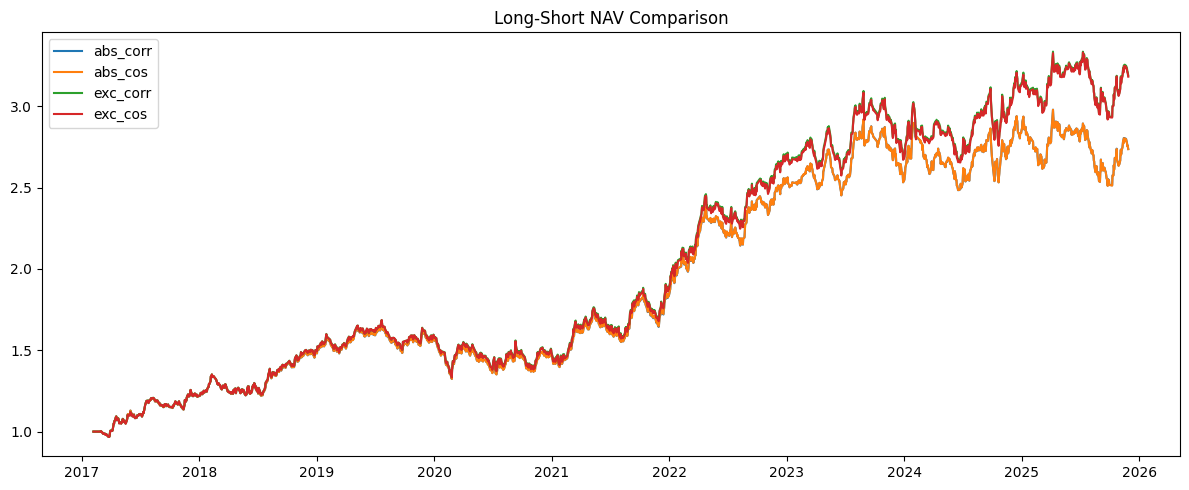

In [ ]:
# Comparison of long–short portfolio performance under different construction methods
plot_ls_nav({
    "abs_corr": res_abs_corr,
    "abs_cos":  res_abs_cos,
    "exc_corr": res_exc_corr,
    "exc_cos":  res_exc_cos,
})

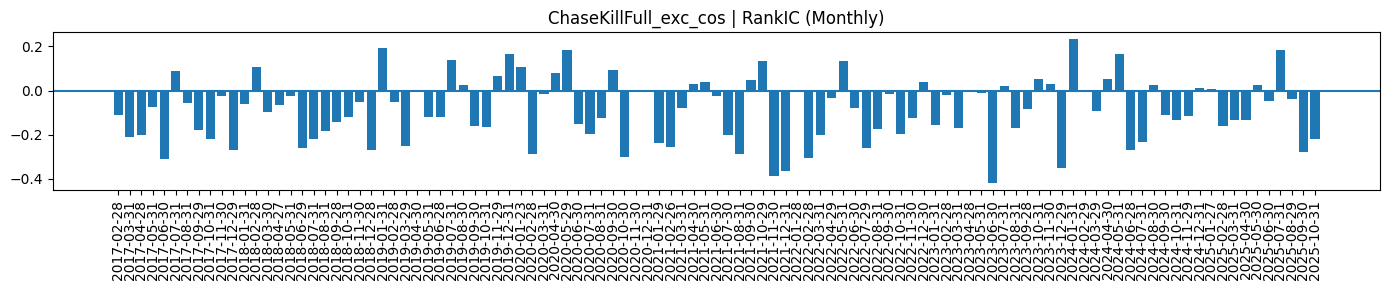

In [95]:
plot_rankic(res_exc_cos.ic_series, "ChaseKillFull_exc_cos")

In [96]:
# Comparison of factor performance under different construction methods
compare_summary_table({
    "abs_corr": res_abs_corr,
    "abs_cos":  res_abs_cos,
    "exc_corr": res_exc_corr,
    "exc_cos":  res_exc_cos,
})


,abs_corr,abs_cos,exc_corr,exc_cos
IC_mean,-3.99%,-3.99%,-4.46%,-4.46%
ICIR,-0.31,-0.31,-0.35,-0.35
RankIC_mean,-7.90%,-7.90%,-8.79%,-8.79%
RankICIR,-0.54,-0.54,-0.61,-0.61
LS_AnnRet,12.67%,12.66%,14.72%,14.70%
LS_AnnVol,13.93%,13.93%,13.71%,13.71%
LS_IR,0.91,0.91,1.07,1.07
LS_MaxDD,-20.58%,-20.63%,-20.81%,-20.92%
LS_MonthlyWinRate,56.60%,56.60%,57.55%,57.55%
Long_AnnRet,11.51%,11.50%,12.15%,12.15%


# 2. The Late-Session Momentum-Chasing Factor as a Stronger Source of Negative Alpha

In this section, we further decompose the full-period momentum-chasing factor along two dimensions: price direction and time of day. Along the price-direction dimension, we use the sign of \( R_t \) as a label and decompose the momentum-chasing factor into a momentum-buying (chasing gains) factor and a momentum-selling (chasing losses) factor. Along the time dimension, we segment the intraday trading period and compare the information content across different time windows.

We find that factor effectiveness exhibits clear regularities, which we attribute to the following reasons:

(1) **Price direction**: Both momentum-buying and momentum-selling are influenced by the intensity of retail investor trading and by retail investor overreaction. These two effects share common features but also differ. Both momentum-buying and momentum-selling imply a higher level of retail participation, which is the source of negative alpha for both. However, a high degree of retail participation is often accompanied by retail overreaction, and the direction of overreaction differs between the two. In the momentum-buying factor, retail overreaction pushes prices upward and contributes negative alpha; in the momentum-selling factor, retail overreaction pushes prices downward and contributes positive alpha. As a result, the two effects reinforce each other in the momentum-buying factor but offset each other in the momentum-selling factor, leading to a stronger negative alpha for the momentum-buying factor.

(2) **Time dimension**: First, from the perspective of trading habits across different investor types, institutional investors tend to trade earlier in the day, while retail investors tend to trade toward the end of the session. As a result, the negative alpha associated with retail behavior is stronger in the late session. Second, late-session retail trading partially reflects expectations about overnight information. As uninformed traders, retail investors rely more heavily on contemporaneous price movements when making decisions. Consequently, momentum-chasing behavior is more pronounced in the late session. We compute momentum-buying factors for different intraday periods and examine their correlation with the absolute magnitude of next-day overnight returns. We find that the larger the next-day overnight absolute move, the stronger the momentum-buying characteristics observed in the late session on the previous day.

Based on the above findings—that the negative alpha of the momentum-buying factor is strongest in the late session—we test factor effectiveness using different cumulative time windows. When using the last 90 minutes of trading (13:31–15:00), the constructed momentum-buying factor exhibits the strongest negative alpha. Therefore, we select the last 90 minutes of trading for each day over the past 20 trading days, focus on minutes with positive excess returns, and compute the cosine similarity between positive excess returns and the excess returns of the subsequent minute to construct the late-session momentum-buying factor.
(The construction steps are detailed in Table 3.)

Table 3: Construction Steps of the Late-Session Momentum-Buying Factor

| Step | Description |
|------|-------------|
| Step 1 | Select 1-minute frequency trading data for each stock between 13:31 and 15:00 over the past 20 trading days; |
| Step 2 | Compute excess returns at each time point and select time points \( t \) with positive excess returns; |
| Step 3 | Compute the excess return of the current minute at time \( t \) (>0) and the excess return of the next minute, denoted as \( R_t \) and \( R_{t+1} \); |
| Step 4 | Calculate the cosine similarity between \( R_t \) and \( R_{t+1} \) as the value of the late-session momentum-buying factor. |


In [97]:
MIN_FOLDER = Path('/Users/zhaoweizhi/Desktop/Quant_Research/data/stock_1min/')
START_TIME = '13:31'
END_TIME   = '15:00'
LOOKBACK_DAYS = 20

factor_rows = []

files = sorted(MIN_FOLDER.glob('*.parquet'))
n_files = len(files)

t0 = time.time()

for si, fp in enumerate(files, start=1):
    ts_code = fp.stem

    # ===== Real-time progress display (same style as your original) =====
    if si == 1 or si % 20 == 0 or si == n_files:
        clear_output(wait=True)
        elapsed = time.time() - t0
        print(
            f"Processing {si}/{n_files} stocks | "
            f"current={ts_code} | "
            f"elapsed={elapsed:.1f}s"
        )

    df = pd.read_parquet(fp, columns=['close', 'adj_factor']).sort_index()

    # ---------- Forward adjustment ----------
    latest_adj = df['adj_factor'].iloc[-1]
    close = df['close'] * (df['adj_factor'] / latest_adj)

    # ---------- Late session 13:31~15:00 ----------
    trade_time = close.index.get_level_values('trade_time')
    hhmm = trade_time.strftime('%H:%M')
    mask = (hhmm >= START_TIME) & (hhmm <= END_TIME)
    close = close.loc[mask]

    # ---------- Daily 1min ret ----------
    ret = close.groupby(level='trade_date', sort=False).pct_change()

    # ---------- Excess ret ----------
    mkt = mkt_median_df['mkt_median_ret'].reindex(ret.index)
    ex_ret = ret - mkt

    # ---------- 20-day rolling buffer: store (Rt, Rt1) ----------
    buf = deque(maxlen=LOOKBACK_DAYS)

    for d, day_ex in ex_ret.groupby(level='trade_date', sort=False):
        x = day_ex.copy()

        if x.shape[0] < 2:
            buf.append(None)
            continue

        # Use trade_time as the intraday minute index
        t = x.index.get_level_values('trade_time')
        x.index = pd.DatetimeIndex(t)

        # ===== Only keep Rt > 0 =====
        pos_idx = x.index[x.values > 0]
        if len(pos_idx) == 0:
            buf.append(None)
            continue

        # Drop the last minute (no Rt+1)
        last_min = x.index[-1]
        pos_idx = pos_idx[pos_idx != last_min]
        if len(pos_idx) == 0:
            buf.append(None)
            continue

        Rt = x.loc[pos_idx].values
        Rt1 = x.shift(-1).loc[pos_idx].values

        m = np.isfinite(Rt) & np.isfinite(Rt1)
        Rt, Rt1 = Rt[m], Rt1[m]
        if len(Rt) == 0:
            buf.append(None)
            continue

        buf.append((Rt, Rt1))

        if len(buf) < LOOKBACK_DAYS:
            continue

        X = np.concatenate([b[0] for b in buf if b is not None])
        Y = np.concatenate([b[1] for b in buf if b is not None])

        if len(X) < 2:
            val = np.nan
        else:
            denom = np.linalg.norm(X) * np.linalg.norm(Y)
            val = np.nan if denom == 0 else float(np.dot(X, Y) / denom)

        factor_rows.append((d, ts_code, val))

# ---------- Output ----------
clear_output(wait=True)
print(f"Done. Total elapsed: {time.time() - t0:.1f}s")

tail_chase_df = (
    pd.DataFrame(
        factor_rows,
        columns=['trade_date', 'ts_code', 'tail_chase_exc_cos']
    )
    .set_index(['trade_date', 'ts_code'])
    .sort_index()
)

tail_chase_factor = tail_chase_df['tail_chase_exc_cos'].unstack('ts_code')


Done. Total elapsed: 12563.5s


In [98]:
tail_chase_factor

ts_code,000001.SZ,000002.SZ,000004.SZ,000005.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,...,920964.BJ,920970.BJ,920971.BJ,920974.BJ,920976.BJ,920978.BJ,920981.BJ,920982.BJ,920985.BJ,920992.BJ
trade_date,,,,,,,,,,,,,,,,,,,,,
2017-02-06,-0.427844,0.078715,-0.285225,-0.234843,-0.125005,NaN,-0.116053,-0.152376,-0.195608,0.118494,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-02-07,-0.447506,0.070244,-0.283160,-0.208349,-0.130164,NaN,-0.115245,-0.145104,-0.179486,0.110085,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-02-08,-0.480805,0.057499,-0.280441,-0.207790,-0.142122,NaN,-0.111930,-0.146677,-0.189140,0.104763,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-02-09,-0.482364,0.045413,-0.277327,-0.210062,-0.147248,NaN,-0.108426,-0.140287,-0.173398,0.101031,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-02-10,-0.459998,0.049417,-0.276243,-0.207781,-0.277382,0.113938,-0.110311,-0.150799,-0.191191,-0.050628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-24,-0.497671,-0.570875,-0.155169,NaN,-0.121110,-0.280001,-0.499112,-0.000944,-0.388368,-0.236040,...,-0.266370,-0.444845,0.086016,-0.233102,-0.214479,-0.158180,-0.198214,0.087321,-0.105285,-0.272999
2025-11-25,-0.505948,-0.574188,-0.116095,NaN,-0.114418,-0.280618,-0.491075,-0.001674,-0.387990,-0.222204,...,-0.263620,-0.436274,0.090005,-0.235842,-0.215548,-0.168720,-0.204179,0.081419,-0.100671,-0.285710
2025-11-26,-0.496978,-0.593963,-0.115456,NaN,-0.124600,-0.294224,-0.492072,-0.008236,-0.399969,-0.221492,...,-0.299366,-0.445140,0.060281,-0.237249,-0.247217,-0.227819,-0.264871,-0.197250,-0.300844,-0.299289


The late-session momentum-chasing factor has an average RankIC of −9.84%. The performance across factor-sorted portfolios is well differentiated with strong monotonicity. The long portfolio delivers an annualized return of 19.54%, with an average monthly turnover rate of 55%, indicating that the long-side return contribution is significant.


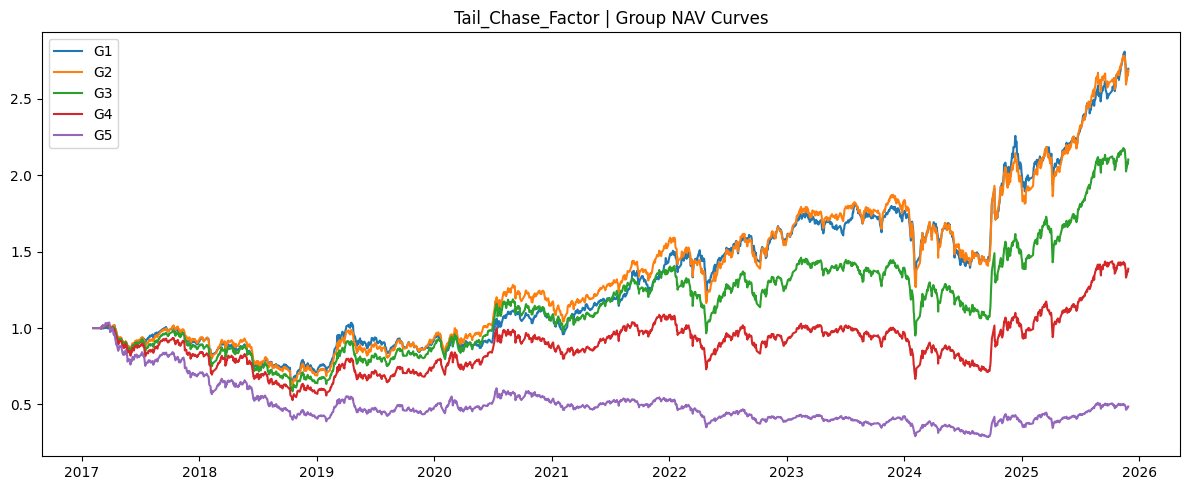

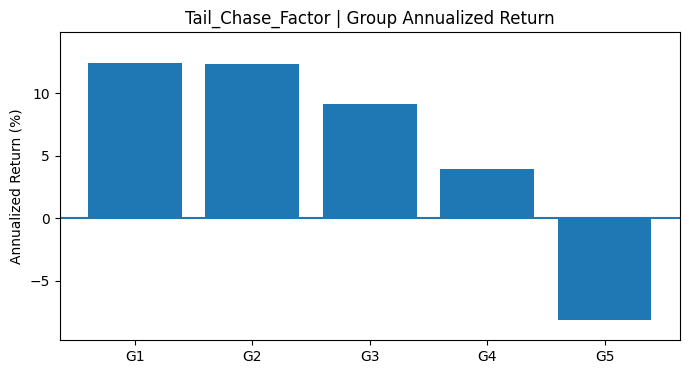

In [99]:
bt = FactorBacktestEngine(n_group=5)
res_tail_chase = bt.run(tail_chase_factor, stock_daily)

plot_group_nav(res_tail_chase.group_nav, "Tail_Chase_Factor")
plot_group_annualized_return(res_tail_chase.group_daily_ret, "Tail_Chase_Factor")


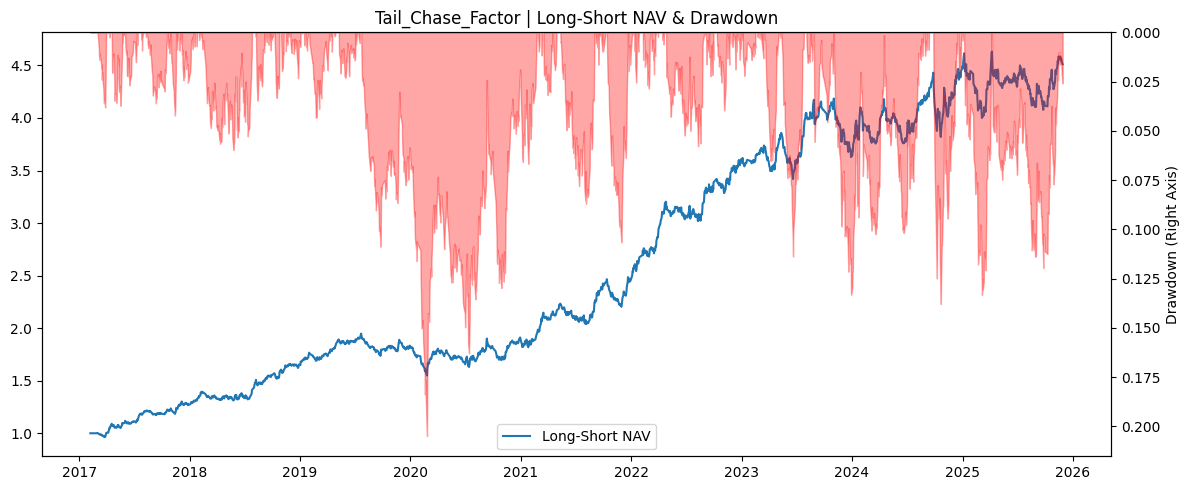

In [100]:
plot_ls_nav_and_drawdown(res_tail_chase.ls_nav, "Tail_Chase_Factor")

In [101]:
show_summary_table(res_tail_chase.summary_table)
show_yearly_table(res_tail_chase.yearly_table)

,IC_mean,ICIR,RankIC_mean,RankICIR,LS_AnnRet,LS_AnnVol,LS_IR,LS_MaxDD,LS_MonthlyWinRate,Long_AnnRet,Long_AnnVol,Long_IR
0,-5.49%,-0.45,-9.84%,-0.70,19.54%,13.94%,1.40,-20.50%,62.26%,12.48%,21.41%,0.58


,YearReturn
Year,
2017,27.17%
2018,29.67%
2019,11.10%
2020,3.98%
2021,33.44%
2022,44.12%
2023,0.96%
2024,23.23%
2025,0.91%
